In [ ]:
# [auto] project-root setup
import os, sys
from pathlib import Path

# 自动向上查找项目根目录 (含 .gitignore 的文件夹)
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / '.gitignore').exists():
    _p = _p.parent
PROJECT_ROOT = _p

# 切换 cwd 到项目根, 使所有相对路径 (Stage1_Exploration/, Refined_Results_v4/ 等) 保持有效
os.chdir(PROJECT_ROOT)
# 让 notebooks 能 `from viz_config import VizConfig`
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
print(f'[setup] PROJECT_ROOT = {PROJECT_ROOT}')


正在读取数据...
正在执行代码 1 的拟合逻辑...
代码 1 拟合成功。
正在执行代码 2 的残差计算逻辑...
正在绘制合并大图...

带标签的合并图已保存至: Stage2_Hypothesis_Verification\1.pdf


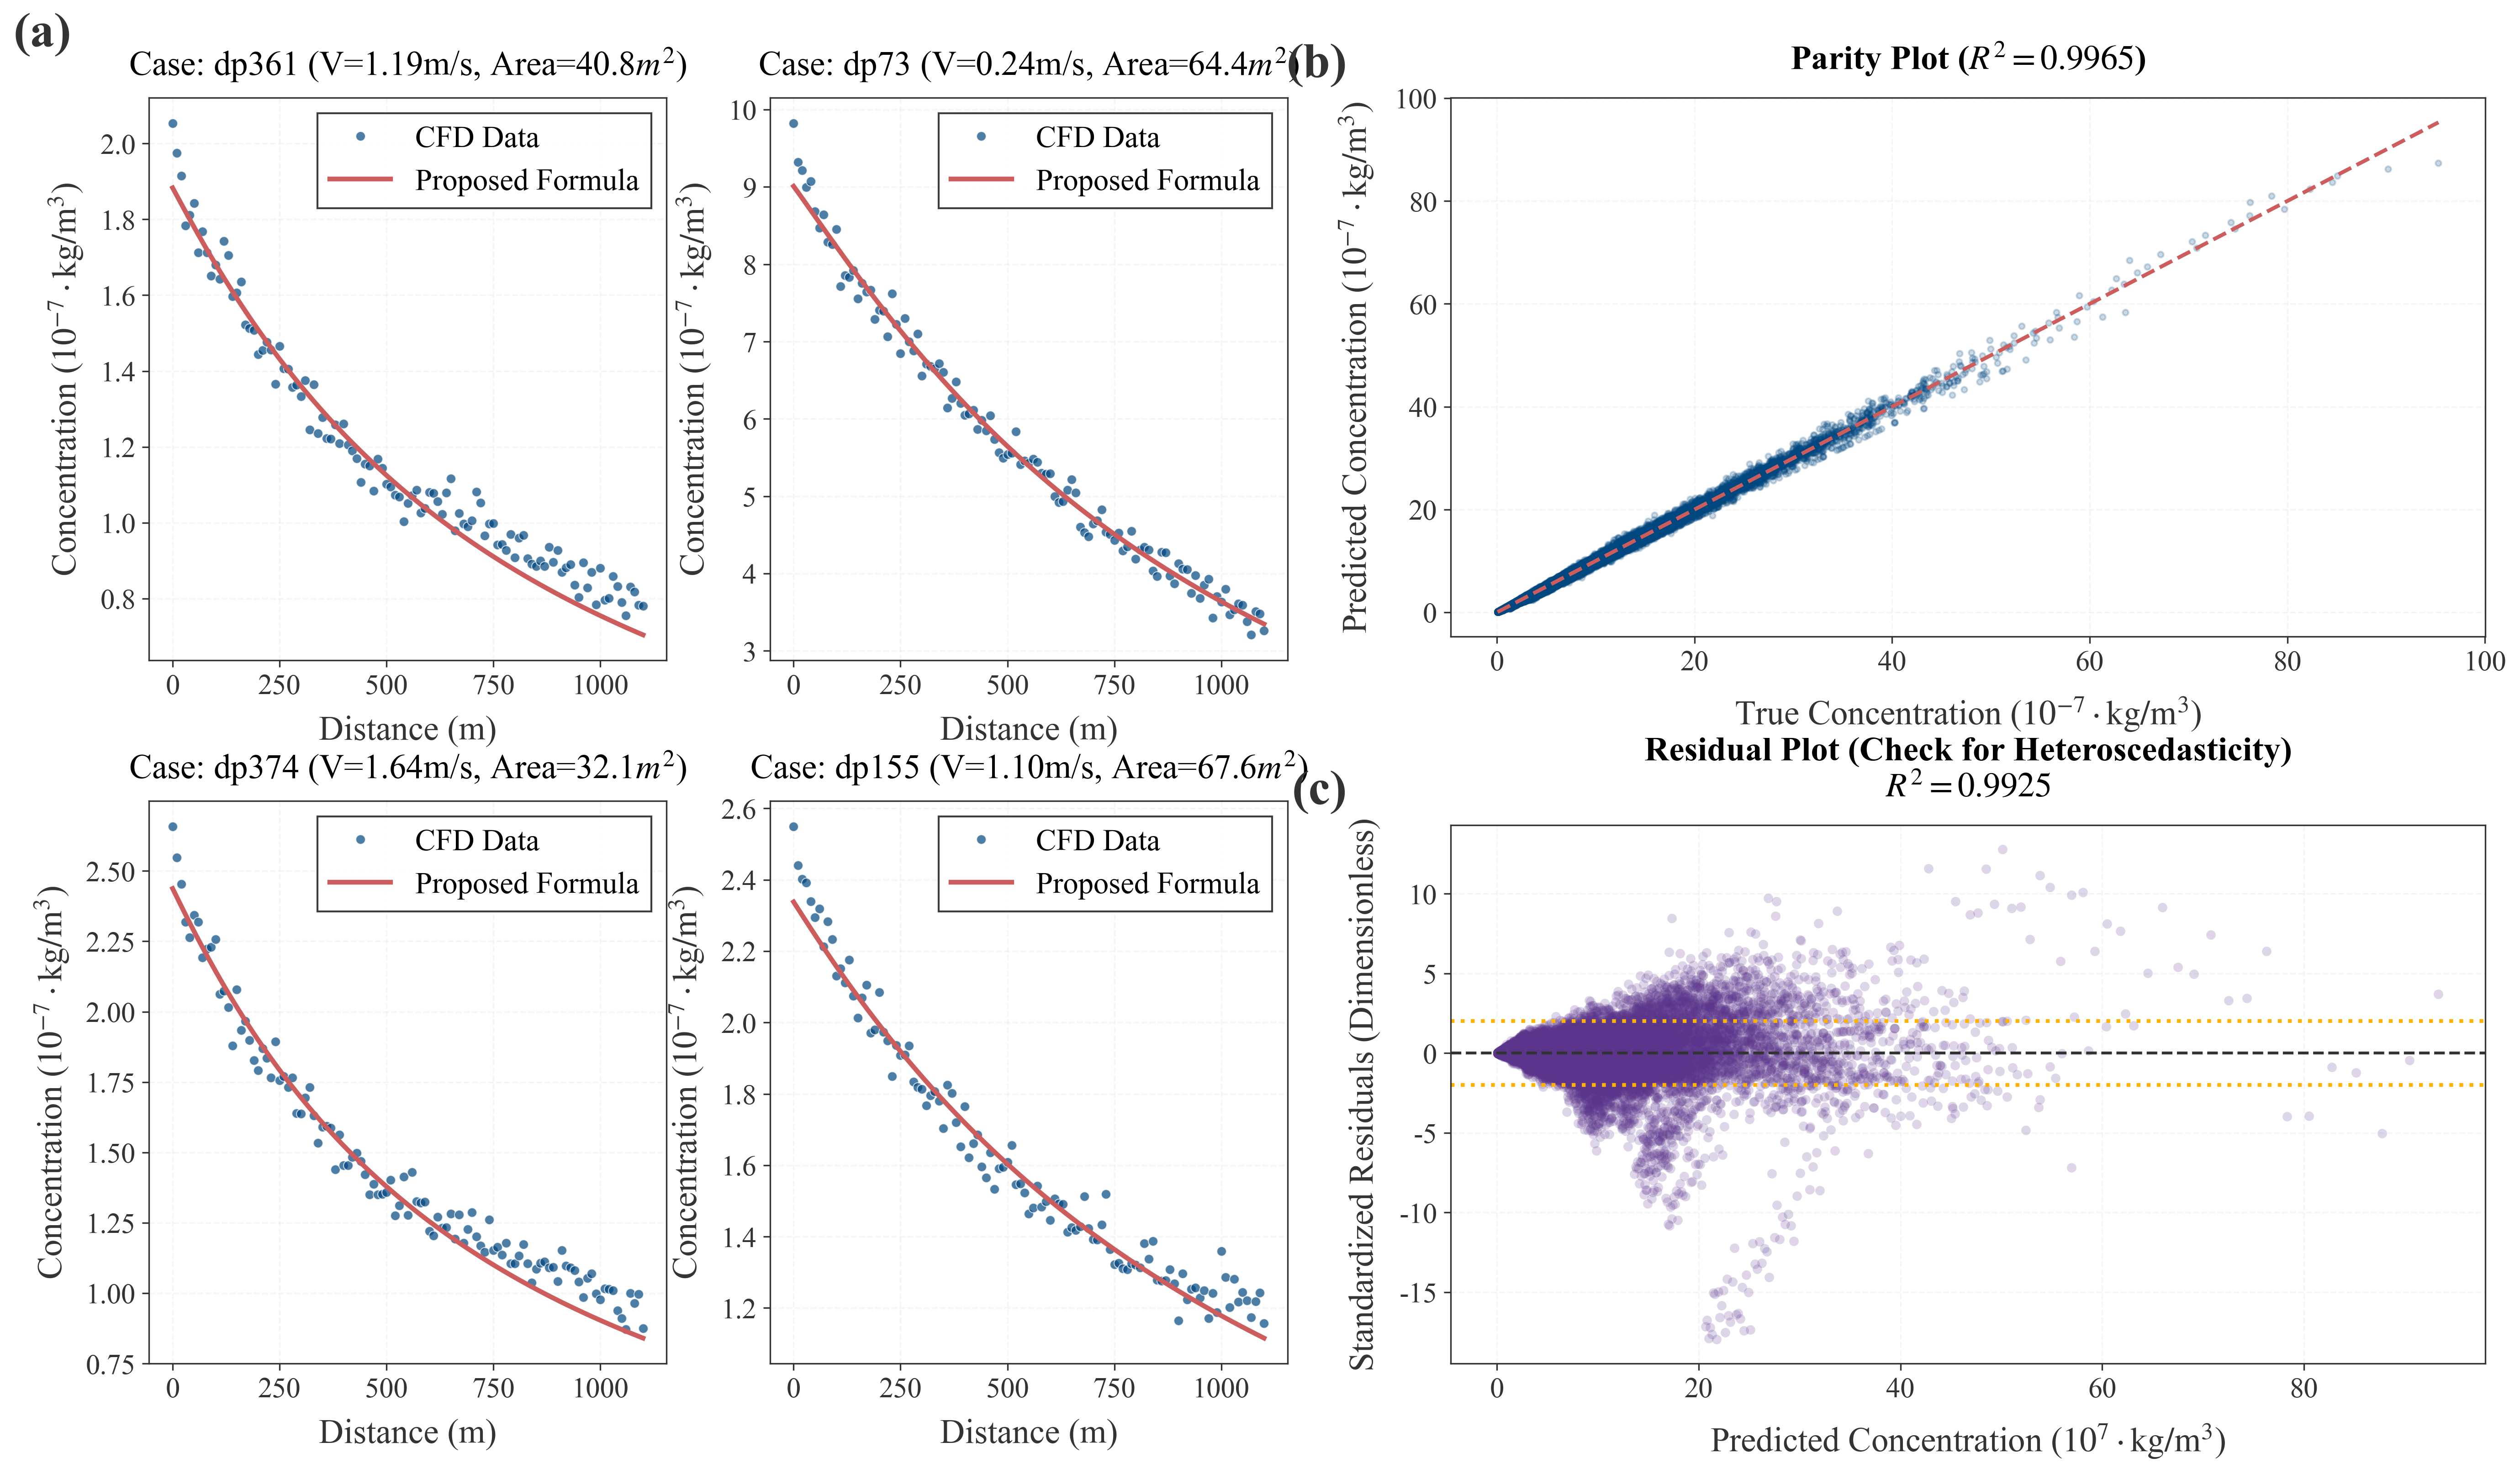

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from viz_config import VizConfig

# ==========================================
# 0. 全局配置与环境初始化
# ==========================================
# 加载统一的绘图风格配置 (viz_config.py)，确保所有图表字体、颜色一致
VizConfig.set_style()

# 定义输出目录，用于存放生成的 PDF 图表
OUTPUT_DIR = "Stage2_Hypothesis_Verification"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 浓度数据的缩放因子，用于避免数值过小导致拟合不稳定
# 原始数据可能是 1e-7 量级，缩放后变为 1.0 量级
SCALE = 1e7

# ==========================================
# 1. 数据准备 (Data Preparation)
# ==========================================
print("正在读取数据...")
if not os.path.exists('data/train_dataset_ready.csv'):
    print("错误：未找到 train_dataset_ready.csv 文件")
    exit()

# 读取包含 CFD 模拟结果的 CSV 文件
df = pd.read_csv('data/train_dataset_ready.csv')

# 对浓度数据进行缩放处理
df['C_in_scaled'] = df['C_in'] * SCALE
df['C_out_scaled'] = df['C_out'] * SCALE

# 提取特征变量用于后续计算
V_in = df['V_in'].values        # 入口风速
Area = df['Area'].values        # 截面积
Dist = df['Distance'].values    # 距离
C_in_scaled = df['C_in_scaled'].values  # 缩放后的入口浓度
C_out_scaled = df['C_out_scaled'].values # 缩放后的出口浓度 (真实值)

# ==========================================
# 2. 逻辑部分 A: 假设公式拟合 (Hypothesis Fitting)
# ==========================================
print("正在执行代码 1 的拟合逻辑...")

# 定义物理假设公式
# 该公式基于物理直觉：浓度随距离衰减，且受风速和截面积影响
def hypothesis_formula(X, a, b, c, d):
    v, area, dist, c_in = X
    # 时间尺度项：距离/速度的平方根，反映扩散时间特征
    time_scale = np.sqrt(dist / (v + 1e-6))
    # 有效面积项：考虑时间尺度对扩散范围的修正
    effective_term = area - b * time_scale + c
    # 分母项：距离与有效面积的组合，类似于扩散方程的解的形式
    # np.maximum 确保分母不会因为有效面积为负而出现物理上不合理的数值
    denominator = (a * dist) / (np.maximum(effective_term, 0.1)) + d
    return c_in / denominator

# 拟合的初始猜测值 (Initial Guess)
p0 = [0.08, 0.6, 26.0, 1.0] 
# 打包自变量
X_data = (V_in, Area, Dist, C_in_scaled)

try:
    # 使用非线性最小二乘法拟合参数
    # bounds 限制参数范围，防止出现无物理意义的负值或过大值
    popt, pcov = curve_fit(hypothesis_formula, X_data, C_out_scaled, p0=p0, 
                           maxfev=20000, bounds=([0, 0, 0, 0.5], [2.0, 10.0, 100.0, 2.0]))
    # 计算拟合后的预测值
    y_pred_fit = hypothesis_formula(X_data, *popt)
    # 计算决定系数 R2，评估拟合优度
    r2_fit = r2_score(C_out_scaled, y_pred_fit)
    print("代码 1 拟合成功。")
except Exception as e:
    print(f"代码 1 拟合出错: {e}")
    exit()

# ==========================================
# 3. 逻辑部分 B: 残差分析 (Residual Analysis)
# ==========================================
print("正在执行代码 2 的残差计算逻辑...")

# 使用已知的第二组参数 (可能来自文献或之前的迭代)
a_2, b_2, c_2, d_2 = 9.851695, 10.058320, 34.511347, -14.437245

# 使用原始比例的数据进行计算 (注意这里重新定义了变量名以免混淆)
C_in_raw = df['C_in'].values * SCALE 
C_true_raw = df['C_out'].values * SCALE

# 计算第二种模型下的预测值
effective_area_2 = Area + c_2 * np.sqrt(V_in) + d_2
denominator_2 = (Dist / effective_area_2) + b_2
C_pred_2 = C_in_raw * (a_2 / denominator_2)

# 计算残差 (真实值 - 预测值)
residuals_2 = C_true_raw - C_pred_2
# 标准化残差 (Residuals / Std_Dev)，用于判断异常值 (通常 >2 或 <-2 为异常)
std_residuals_2 = residuals_2 / np.std(residuals_2)
# 计算该模型的 R2
r2_2 = r2_score(C_true_raw, C_pred_2)

# ==========================================
# 4. 绘图合并 (Combined Visualization)
# ==========================================
print("正在绘制合并大图...")

# 创建大图画布，设置为 22x12 英寸
fig = plt.figure(figsize=(22, 12)) 
# 使用 GridSpec 将画布分为左右两部分 (比例 1.1:1)
outer_gs = gridspec.GridSpec(1, 2, width_ratios=[1.1, 1], wspace=0.15)

# --- 左侧区域: 4个典型案例的拟合曲线展示 ---
# 2x2 子图布局
left_gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[0], hspace=0.25, wspace=0.2)
np.random.seed(42) # 固定随机种子确保复现性
# 随机抽取 4 个 Case 进行展示
sample_cases = np.random.choice(df['Case'].unique(), 4, replace=False)

unit_c = r"($10^{-7} \cdot \text{kg/m}^3$)"

for i, case_id in enumerate(sample_cases):
    ax = fig.add_subplot(left_gs[i // 2, i % 2])
    
    # 仅在左上角第一个子图添加 '(a)' 标签
    if i == 0:
        ax.text(-0.15, 1.15, '(a)', transform=ax.transAxes, 
                fontsize=26, fontweight='bold', va='top', ha='right', color=VizConfig.COLOR_AXIS)

    # 提取当前 Case 的数据并按距离排序
    case_data = df[df['Case'] == case_id].sort_values('Distance')
    # 使用拟合好的参数计算预测曲线
    pred_c = hypothesis_formula((case_data['V_in'].values, case_data['Area'].values, 
                                 case_data['Distance'].values, case_data['C_in_scaled'].values), *popt)
    
    # 绘制 CFD 真实数据点 (深蓝色)
    ax.plot(case_data['Distance'].values, case_data['C_out_scaled'].values, 'o', 
            color=VizConfig.COLOR_MAIN, markersize=5, 
            alpha=0.7, label='CFD Data', rasterized=True, markeredgecolor='white', markeredgewidth=0.5)
    
    # 绘制拟合曲线 (红色)
    ax.plot(case_data['Distance'].values, pred_c, 
            color=VizConfig.COLOR_HIGHLIGHT, linewidth=2.5, label='Proposed Formula')
    
    # 设置子图标题和坐标轴标签
    ax.set_title(f"Case: {case_id} (V={case_data['V_in'].values[0]:.2f}m/s, Area={case_data['Area'].values[0]:.1f}$m^2$)", 
                 fontsize=VizConfig.LABEL_SIZE, pad=12)
    ax.set_xlabel("Distance (m)", fontsize=VizConfig.LABEL_SIZE, labelpad=8)
    ax.set_ylabel(f"Concentration {unit_c}", fontsize=VizConfig.LABEL_SIZE, labelpad=8)
    ax.tick_params(axis='both', labelsize=VizConfig.TICK_SIZE)
    ax.legend(fontsize=VizConfig.LEGEND_SIZE)
    ax.grid(True, alpha=0.3)

# --- 右侧区域: 统计分析图 (Parity Plot & Residual Plot) ---
right_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[1], hspace=0.35)

# --- 右上: 对角线图 (Parity Plot) ---
# 用于展示预测值与真实值的一致性
ax_parity = fig.add_subplot(right_gs[0])

# 添加 '(b)' 标签
ax_parity.text(-0.1, 1.1, '(b)', transform=ax_parity.transAxes, 
               fontsize=26, fontweight='bold', va='top', ha='right', color=VizConfig.COLOR_AXIS)

# 绘制散点 (真实值 vs 预测值)
ax_parity.plot(C_out_scaled, y_pred_fit, 'o', color=VizConfig.COLOR_MAIN, markersize=3, alpha=0.2, rasterized=True)
# 绘制对角线 (理想情况 y=x)
ax_parity.plot([C_out_scaled.min(), C_out_scaled.max()], [C_out_scaled.min(), C_out_scaled.max()], 
               linestyle='--', color=VizConfig.COLOR_HIGHLIGHT, linewidth=2)

ax_parity.set_xlabel(f"True Concentration {unit_c}", fontsize=VizConfig.LABEL_SIZE, labelpad=10)
ax_parity.set_ylabel(f"Predicted Concentration {unit_c}", fontsize=VizConfig.LABEL_SIZE, labelpad=10)
ax_parity.set_title(f"Parity Plot ($R^2={r2_fit:.4f}$)", fontsize=VizConfig.TITLE_SIZE, pad=15, fontweight='bold')
ax_parity.tick_params(labelsize=VizConfig.TICK_SIZE)
ax_parity.grid(True, alpha=0.3)

# --- 右下: 残差图 (Residual Plot) ---
# 用于检查异方差性 (Heteroscedasticity) 和模型偏差
ax_resid = fig.add_subplot(right_gs[1])

# 添加 '(c)' 标签
ax_resid.text(-0.1, 1.1, '(c)', transform=ax_resid.transAxes, 
              fontsize=26, fontweight='bold', va='top', ha='right', color=VizConfig.COLOR_AXIS)

# 绘制标准化残差散点 (紫色)
ax_resid.plot(C_pred_2, std_residuals_2, 'o', color=VizConfig.COLOR_PALETTE[5], markersize=5, alpha=0.2, rasterized=True, markeredgecolor='none') 

# 绘制辅助线：0轴，以及 +/- 2 标准差警戒线
ax_resid.axhline(0, color=VizConfig.COLOR_AXIS, linestyle='--', linewidth=1.5)
ax_resid.axhline(2, color=VizConfig.COLOR_WARNING, linestyle=':', linewidth=2)
ax_resid.axhline(-2, color=VizConfig.COLOR_WARNING, linestyle=':', linewidth=2)

ax_resid.set_xlabel(r"Predicted Concentration ($10^7 \cdot \text{kg/m}^3$)", fontsize=VizConfig.LABEL_SIZE, labelpad=10)
ax_resid.set_ylabel("Standardized Residuals (Dimensionless)", fontsize=VizConfig.LABEL_SIZE, labelpad=10)
ax_resid.set_title(f"Residual Plot (Check for Heteroscedasticity)\n$R^2 = {r2_2:.4f}$", 
                   fontsize=VizConfig.TITLE_SIZE, fontweight='bold', pad=15)
ax_resid.tick_params(labelsize=VizConfig.TICK_SIZE)
ax_resid.grid(True, alpha=0.3)

# ==========================================
# 5. 保存输出
# ==========================================
# 调整布局以避免重叠，pad_inches 控制边缘留白
# tight_layout 虽然有警告但在复杂 GridSpec 中通常能起作用
# 也可以尝试 fig.subplots_adjust() 手动调整
# plt.tight_layout() 
output_path = os.path.join(OUTPUT_DIR, "1.pdf")
plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.1) 

print(f"\n带标签的合并图已保存至: {output_path}")
plt.show()